# HealthCast — COVID-19 Case Forecasting (India)

This final version uses a **direct 7-day forecasting strategy** instead of
recursive one-step forecasting.

The pipeline is designed to avoid the two methodological problems identified
earlier:

1. **Training-only outlier caps:** caps are learned from the training period
   and applied only to model features.
2. **Original/uncapped evaluation targets:** predictions are evaluated against
   the real observed case counts, not clipped targets.
3. **Direct multi-step forecasting:** one model predicts all 7 future days at
   once, so day-2 through day-7 predictions do not consume earlier model
   predictions and compound their errors.
4. **Chronological train/validation/test split:** validation is used for model
   configuration selection; the final test period remains untouched.
5. **Persistence baseline:** every model is compared against "tomorrow looks
   like today" across the same 7-day horizons.
6. **Forecast gate:** the Streamlit app only displays a state forecast if the
   final held-out test MAE beats the persistence baseline.
7. **Production artifacts:** after evaluation, a production model is retrained
   on all available historical data using the same direct 7-day formulation.


In [48]:
# Imports
import json
import warnings
from pathlib import Path

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

import joblib

warnings.filterwarnings("ignore")

# --- Project-wide configuration ---
GROWTH_CLIP = 0.30
OUTLIER_QUANTILE = 0.99
FORECAST_DAYS = 7
SANITY_BOUND_PCT = 0.25  # operational display rule only; never used for evaluation
STATES = ["TN", "KA", "MH", "DL", "KL"]

# Chronological split points.
TRAIN_FRAC = 0.70
VALIDATION_FRAC = 0.10
TEST_FRAC = 0.20

# Small validation grid. Selection is based only on the validation period.
RF_CONFIGS = [
    {
        "n_estimators": 300,
        "max_depth": 8,
        "min_samples_split": 5,
        "min_samples_leaf": 2,
    },
    {
        "n_estimators": 400,
        "max_depth": 12,
        "min_samples_split": 5,
        "min_samples_leaf": 2,
    },
    {
        "n_estimators": 500,
        "max_depth": None,
        "min_samples_split": 5,
        "min_samples_leaf": 2,
    },
]

CACHE_DIR = Path("data_cache")
CACHE_DIR.mkdir(exist_ok=True)


In [49]:
print(pd.__version__)

2.2.3


## 1. Data Loading

Both APIs are fetched live. If a request fails (rate limit, endpoint change,
no network), we fall back to a local cache under `data_cache/` if one exists
from a previous run, and raise a clear error if neither is available — instead
of silently continuing with stale or empty data.

In [50]:
# National time series (disease.sh)
national_cache = CACHE_DIR / "national_cases.csv"

try:
    url = "https://disease.sh/v3/covid-19/historical/India?lastdays=all"
    resp = requests.get(url, timeout=15)
    resp.raise_for_status()
    cases = resp.json()["timeline"]["cases"]
    df_cases = pd.DataFrame(list(cases.items()), columns=["date", "cases"])
    df_cases["date"] = pd.to_datetime(df_cases["date"], format="%m/%d/%y")
    df_cases.to_csv(national_cache, index=False)
    print("Fetched national data live:", df_cases.shape)
except Exception as e:
    if national_cache.exists():
        df_cases = pd.read_csv(national_cache, parse_dates=["date"])
        print(f"Live fetch failed ({e}); loaded cached national data:", df_cases.shape)
    else:
        raise RuntimeError(
            f"Could not fetch national data ({e}) and no cache exists at {national_cache}. "
            "Run this notebook once with network access to disease.sh to populate the cache."
        )


Fetched national data live: (1143, 2)


In [51]:
# State-wise time series (covid19india.org)
state_cache = CACHE_DIR / "state_wise_daily.csv"

try:
    url_state = "https://api.covid19india.org/csv/latest/state_wise_daily.csv"
    df_state = pd.read_csv(url_state)
    df_state.to_csv(state_cache, index=False)
    print("Fetched state-wise data live:", df_state.shape)
except Exception as e:
    if state_cache.exists():
        df_state = pd.read_csv(state_cache)
        print(f"Live fetch failed ({e}); loaded cached state data:", df_state.shape)
    else:
        raise RuntimeError(
            f"Could not fetch state-wise data ({e}) and no cache exists at {state_cache}. "
            "Run this notebook once with network access to covid19india.org to populate the cache."
        )

df_confirmed = df_state[df_state["Status"] == "Confirmed"].copy()
df_confirmed["Date"] = pd.to_datetime(df_confirmed["Date"], format="%d-%b-%y")
df_confirmed = df_confirmed.sort_values("Date").reset_index(drop=True)

missing_by_state = {st: df_confirmed[st].isna().sum() for st in STATES if st in df_confirmed.columns}
print("Missing-day counts by state (before fill):", missing_by_state)


Fetched state-wise data live: (1524, 42)
Missing-day counts by state (before fill): {'TN': np.int64(0), 'KA': np.int64(0), 'MH': np.int64(0), 'DL': np.int64(0), 'KL': np.int64(0)}


## 2. Feature Engineering

The model uses historical case-count features as inputs.

**Important distinction:**

- Capped case counts → model features
- Original/uncapped future case counts → targets

The target is now a vector:

```text
[t+1, t+2, t+3, t+4, t+5, t+6, t+7]
```

This makes the forecasting problem **direct multi-step forecasting** rather
than recursive one-step forecasting.


In [52]:
def make_feature_row(history, feature_cap):
    """Build exactly one model-input row from the latest observed history.

    The cap is applied only while constructing features.
    """
    capped = np.asarray(history, dtype=float).copy()
    capped = np.clip(capped, 0, feature_cap)

    if len(capped) < 14:
        raise ValueError("At least 14 historical observations are required.")

    growth_rate = 0.0 if capped[-2] == 0 else (capped[-1] - capped[-2]) / capped[-2]
    growth_rate = np.clip(growth_rate, -GROWTH_CLIP, GROWTH_CLIP)

    return pd.DataFrame(
        [[
            capped[-1],
            capped[-2],
            capped[-3],
            capped[-7],
            capped[-14],
            np.mean(capped[-7:]),
            np.mean(capped[-14:]),
            np.std(capped[-7:]),
            growth_rate,
        ]],
        columns=FEATURES,
    )


FEATURES = [
    "lag_1", "lag_2", "lag_3", "lag_7", "lag_14",
    "rolling_avg_7", "rolling_avg_14",
    "rolling_std_7", "growth_rate",
]


def fit_outlier_cap(series, train_end):
    """Learn cap using ONLY observations before train_end."""
    train_values = pd.Series(series).iloc[:train_end]
    cap = train_values.quantile(OUTLIER_QUANTILE)
    return float(cap)


def build_direct_dataset(series, feature_cap, anchor_start, anchor_end):
    """Create direct 7-day samples.

    For anchor t:
        X = features from observations through t
        y = original observed values t+1 ... t+7

    anchor_end is exclusive and must satisfy t+7 < len(series).
    """
    series = np.asarray(series, dtype=float)
    rows = []
    targets = []

    for t in range(anchor_start, anchor_end):
        if t < 13 or t + FORECAST_DAYS >= len(series):
            continue

        X_row = make_feature_row(series[: t + 1], feature_cap)
        rows.append(X_row.iloc[0].values)
        targets.append(series[t + 1 : t + 1 + FORECAST_DAYS])

    if not rows:
        return pd.DataFrame(columns=FEATURES), np.empty((0, FORECAST_DAYS))

    return (
        pd.DataFrame(rows, columns=FEATURES),
        np.asarray(targets, dtype=float),
    )


def make_model(config):
    return RandomForestRegressor(
        **config,
        random_state=42,
        n_jobs=-1,
    )


def evaluate_direct_model(model, X, y):
    pred = np.asarray(model.predict(X), dtype=float)
    mae_by_horizon = np.mean(np.abs(y - pred), axis=0)
    rmse_by_horizon = np.sqrt(np.mean((y - pred) ** 2, axis=0))
    return {
        "pred": pred,
        "mae": float(np.mean(mae_by_horizon)),
        "rmse": float(np.mean(rmse_by_horizon)),
        "mae_by_horizon": mae_by_horizon,
        "rmse_by_horizon": rmse_by_horizon,
    }


def naive_direct_predictions(X_raw_series, anchor_indices):
    """Persistence baseline for each anchor: repeat the current case count 7 times."""
    series = np.asarray(X_raw_series, dtype=float)
    return np.asarray([
        [series[t]] * FORECAST_DAYS
        for t in anchor_indices
    ], dtype=float)


def train_select_refit(series):
    """Chronological validation + untouched test evaluation + production refit.

    Returns:
        production_model, production_cap, metrics, selected_config
    """
    series = np.asarray(series, dtype=float)
    n = len(series)

    train_boundary = int(n * TRAIN_FRAC)
    test_boundary = int(n * (TRAIN_FRAC + VALIDATION_FRAC))

    # Validation/test samples are separated by their forecast horizons.
    train_anchor_end = train_boundary - FORECAST_DAYS
    validation_anchor_start = train_boundary
    validation_anchor_end = test_boundary - FORECAST_DAYS
    test_anchor_start = test_boundary
    test_anchor_end = n - FORECAST_DAYS

    if train_anchor_end <= 14 or validation_anchor_end <= validation_anchor_start:
        raise ValueError("Not enough history for train/validation/test direct forecasting.")

    # Validation cap is learned only from the training period.
    validation_cap = fit_outlier_cap(series, train_boundary)

    X_train, y_train = build_direct_dataset(
        series, validation_cap, 14, train_anchor_end
    )
    X_val, y_val = build_direct_dataset(
        series, validation_cap, validation_anchor_start, validation_anchor_end
    )

    if len(X_train) == 0 or len(X_val) == 0:
        raise ValueError("Train/validation direct datasets are empty.")

    validation_results = []

    for config in RF_CONFIGS:
        candidate = make_model(config)
        candidate.fit(X_train, y_train)
        result = evaluate_direct_model(candidate, X_val, y_val)

        validation_results.append({
            "config": config,
            "mae": result["mae"],
            "rmse": result["rmse"],
        })

    selected = min(validation_results, key=lambda x: x["mae"])
    selected_config = selected["config"]

    # Final test cap is learned only from train + validation observations.
    test_cap = fit_outlier_cap(series, test_boundary)

    X_train_val, y_train_val = build_direct_dataset(
        series, test_cap, 14, test_boundary - FORECAST_DAYS
    )
    X_test, y_test = build_direct_dataset(
        series, test_cap, test_anchor_start, test_anchor_end
    )

    final_eval_model = make_model(selected_config)
    final_eval_model.fit(X_train_val, y_train_val)

    test_result = evaluate_direct_model(final_eval_model, X_test, y_test)

    test_anchor_indices = list(range(test_anchor_start, test_anchor_end))
    naive_test = naive_direct_predictions(series, test_anchor_indices)
    naive_mae_by_horizon = np.mean(np.abs(y_test - naive_test), axis=0)
    naive_rmse_by_horizon = np.sqrt(np.mean((y_test - naive_test) ** 2, axis=0))

    model_mae = test_result["mae"]
    naive_mae = float(np.mean(naive_mae_by_horizon))

    # Production model: retrain on all usable historical samples.
    production_cap = fit_outlier_cap(series, n)
    X_prod, y_prod = build_direct_dataset(
        series, production_cap, 14, n - FORECAST_DAYS
    )

    production_model = make_model(selected_config)
    production_model.fit(X_prod, y_prod)

    metrics = {
        "mae": model_mae,
        "rmse": test_result["rmse"],
        "naive_mae": naive_mae,
        "naive_rmse": float(np.mean(naive_rmse_by_horizon)),
        "target_mean": float(np.mean(y_test)),
        "beats_naive": bool(model_mae < naive_mae),
        "mae_by_horizon": test_result["mae_by_horizon"].tolist(),
        "rmse_by_horizon": test_result["rmse_by_horizon"].tolist(),
        "naive_mae_by_horizon": naive_mae_by_horizon.tolist(),
        "naive_rmse_by_horizon": naive_rmse_by_horizon.tolist(),
        "selected_config": selected_config,
        "validation_results": validation_results,
        "test_start_index": test_anchor_start,
        "test_end_index": test_anchor_end,
    }

    return production_model, production_cap, metrics


## 3. National Direct 7-Day Model

The national model is evaluated using the same direct multi-step framework:

- chronological train/validation/test split;
- validation-based Random Forest configuration selection;
- untouched test evaluation;
- persistence baseline;
- production refit on all available history.


In [53]:
df_cases_sorted = (
    df_cases[df_cases["date"] >= "2020-03-01"]
    .sort_values("date")
    .reset_index(drop=True)
)

df_cases_sorted["daily_cases"] = df_cases_sorted["cases"].diff().fillna(0)
df_cases_sorted.loc[df_cases_sorted["daily_cases"] < 0, "daily_cases"] = 0

national_series = df_cases_sorted["daily_cases"].values.astype(float)

national_model, national_cap, national_metrics = train_select_refit(
    national_series
)

print("National selected configuration:", national_metrics["selected_config"])
print(f"National test MAE: {national_metrics['mae']:.1f}")
print(f"National naive MAE: {national_metrics['naive_mae']:.1f}")
print(f"National beats naive: {national_metrics['beats_naive']}")


National selected configuration: {'n_estimators': 300, 'max_depth': 8, 'min_samples_split': 5, 'min_samples_leaf': 2}
National test MAE: 1539.6
National naive MAE: 1269.5
National beats naive: False


In [54]:
# National 7-day test performance by forecast horizon

print("Horizon | Model MAE | Naive MAE")
for h, (m, n) in enumerate(
    zip(
        national_metrics["mae_by_horizon"],
        national_metrics["naive_mae_by_horizon"],
    ),
    start=1,
):
    print(f"Day +{h}: {m:.1f} | {n:.1f}")

print()
print(
    f"Average model MAE: {national_metrics['mae']:.1f} | "
    f"Average naive MAE: {national_metrics['naive_mae']:.1f}"
)


Horizon | Model MAE | Naive MAE
Day +1: 1198.8 | 1073.3
Day +2: 1354.2 | 1311.2
Day +3: 1450.9 | 1390.8
Day +4: 1491.9 | 1366.9
Day +5: 1611.7 | 1322.3
Day +6: 1716.2 | 1214.7
Day +7: 1953.4 | 1207.7

Average model MAE: 1539.6 | Average naive MAE: 1269.5


In [55]:
# National feature importance from the production model

importance = pd.Series(
    national_model.feature_importances_,
    index=FEATURES,
).sort_values(ascending=False)

print(importance)


lag_1             0.943319
lag_14            0.020270
rolling_avg_14    0.008969
lag_7             0.007409
lag_2             0.007259
rolling_avg_7     0.004446
rolling_std_7     0.003313
lag_3             0.003198
growth_rate       0.001816
dtype: float64


## 4. Per-State Direct 7-Day Models

Each state receives its own direct multi-output Random Forest.

A model is considered forecast-worthy only if its **average 7-day test MAE**
beats the persistence baseline on the untouched test period.


In [56]:
state_models = {}
state_metrics = {}
state_caps = {}

for st in STATES:
    if st not in df_confirmed.columns:
        print(f"Skipping {st}: not present in state data.")
        continue

    series_df = (
        df_confirmed[["Date", st]]
        .rename(columns={st: "daily_cases"})
        .copy()
    )

    series_df["daily_cases"] = series_df["daily_cases"].ffill().bfill()
    series_df.loc[series_df["daily_cases"] < 0, "daily_cases"] = 0

    if len(series_df) < 120:
        print(f"Skipping {st}: not enough history ({len(series_df)} rows).")
        continue

    series = series_df["daily_cases"].values.astype(float)

    try:
        model, production_cap, metrics = train_select_refit(series)
    except ValueError as e:
        print(f"Skipping {st}: {e}")
        continue

    state_models[st] = model
    state_caps[st] = production_cap
    state_metrics[st] = metrics

metrics_table = pd.DataFrame({
    st: {
        "mae": m["mae"],
        "rmse": m["rmse"],
        "naive_mae": m["naive_mae"],
        "naive_rmse": m["naive_rmse"],
        "target_mean": m["target_mean"],
        "beats_naive": m["beats_naive"],
        "mae_pct_of_mean": m["mae"] / m["target_mean"] if m["target_mean"] else np.nan,
    }
    for st, m in state_metrics.items()
}).T

print(metrics_table.round(3))


             mae          rmse    naive_mae   naive_rmse   target_mean  \
TN  10497.213733  14881.879416  2265.554887  2865.925463  15207.190977   
KA  11284.369522  17323.968742  3088.473684  4593.877783  15763.633083   
MH    6741.32772   11350.76465   3508.27218  5470.193411  19889.882707   
DL   2494.220057   5088.115076  1207.251128  2395.395991   3807.162406   
KL   12471.66734  15953.153701  3986.206015  5334.718739  20229.133835   

   beats_naive mae_pct_of_mean  
TN       False         0.69028  
KA       False        0.715848  
MH       False        0.338933  
DL       False        0.655139  
KL       False         0.61652  


## 5. Direct 7-Day Operational Forecasting

The production model predicts all seven future days in one call.

There is **no recursive feedback loop**:

```text
latest 14+ observed days
        ↓
one feature vector
        ↓
model.predict(...)
        ↓
[t+1, t+2, ..., t+7]
```

This removes the error-compounding mechanism of the previous recursive approach.


In [57]:
def forecast_from_direct_model(
    series,
    model,
    feature_cap,
    apply_sanity_bound=True,
):
    """Predict all seven future days directly from the latest observations."""
    series = pd.Series(series).ffill().bfill().astype(float).values

    if len(series) < 14:
        raise ValueError(f"Need at least 14 days of history, got {len(series)}.")

    feature_vec = make_feature_row(series, feature_cap)
    preds = np.asarray(model.predict(feature_vec)[0], dtype=float)

    # Sanity bound is a presentation/operational rule only.
    if apply_sanity_bound:
        latest = max(float(series[-1]), 0.0)
        bounded = []
        for pred in preds:
            lower = latest * (1 - SANITY_BOUND_PCT)
            upper = latest * (1 + SANITY_BOUND_PCT)
            pred = float(np.clip(pred, lower, upper))
            bounded.append(max(pred, 0.0))
            latest = pred
        preds = np.asarray(bounded)

    return preds.tolist()


In [58]:
state_forecasts = {}

for st, model in state_models.items():
    state_forecasts[st] = forecast_from_direct_model(
        df_confirmed[st].values,
        model,
        state_caps[st],
        apply_sanity_bound=True,
    )

for st, preds in state_forecasts.items():
    print(st, [round(p, 1) for p in preds])


TN [1752.6, 1759.6, 1780.9, 1807.4, 1837.2, 1863.7, 1877.9]
KA [1636.0, 1667.8, 1716.1, 1700.7, 1677.7, 1648.3, 1581.2]
MH [6266.8, 6502.6, 6475.6, 6386.3, 6228.2, 5770.9, 6082.1]
DL [55.2, 58.9, 62.5, 61.6, 63.3, 60.3, 60.7]
KL [20058.7, 19201.4, 19332.9, 20227.3, 19574.7, 18007.3, 20220.8]


## 6. Final 7-Day Direct Backtest

This is a separate diagnostic from the broader 20% test evaluation.

For each state, the model is trained on all observations before the final
7-day window and predicts those seven days **directly in one call**.

The held-out targets remain the original/uncapped observations.


In [59]:
backtest_results = {}

for st in state_models:
    series = (
        df_confirmed[st]
        .ffill()
        .bfill()
        .astype(float)
        .values
    )

    if len(series) <= FORECAST_DAYS + 30:
        continue

    holdout_actual = series[-FORECAST_DAYS:]
    train_series = series[:-FORECAST_DAYS]

    cap_bt = fit_outlier_cap(train_series, len(train_series))

    # Training samples stop early enough that no training target touches
    # the final 7-day holdout.
    X_bt, y_bt = build_direct_dataset(
        train_series,
        cap_bt,
        14,
        len(train_series) - FORECAST_DAYS,
    )

    if len(X_bt) < 30:
        continue

    selected_config = state_metrics[st]["selected_config"]
    m_bt = make_model(selected_config)
    m_bt.fit(X_bt, y_bt)

    # Direct forecast of the final 7 days.
    pred_bt = np.asarray(
        m_bt.predict(make_feature_row(train_series, cap_bt))[0],
        dtype=float,
    )

    bt_mae_by_horizon = np.abs(holdout_actual - pred_bt)
    bt_naive = np.repeat(train_series[-1], FORECAST_DAYS)
    bt_naive_error = np.abs(holdout_actual - bt_naive)

    bt_mae = float(np.mean(bt_mae_by_horizon))
    bt_naive_mae = float(np.mean(bt_naive_error))

    backtest_results[st] = {
        "backtest_mae": bt_mae,
        "naive_mae": bt_naive_mae,
        "beats_naive": bool(bt_mae < bt_naive_mae),
        "mae_by_horizon": bt_mae_by_horizon.tolist(),
        "naive_mae_by_horizon": bt_naive_error.tolist(),
    }

backtest_table = pd.DataFrame(backtest_results).T

print(backtest_table[["backtest_mae", "naive_mae", "beats_naive"]].round(2))
print()
print("Targets are ORIGINAL/UNCAPPED held-out observations.")
print("Forecasting is DIRECT: all seven days are predicted in one model call.")


   backtest_mae    naive_mae beats_naive
TN    302.45975   150.857143       False
KA   244.925438        317.0        True
MH   477.349652   641.285714        True
DL    12.757328    18.571429        True
KL  2039.922151  2013.285714       False

Targets are ORIGINAL/UNCAPPED held-out observations.
Forecasting is DIRECT: all seven days are predicted in one model call.


## 7. Rolling 7-Day Robustness Validation

The final holdout above tests one final 7-day period. This section checks whether
the direct 7-day forecasting approach is consistently better than the persistence
baseline across four earlier historical 7-day windows.

Each window is trained independently using only data available before that window.
The outlier cap is learned from that training history only, and evaluation targets
remain the original/uncapped observations.

A state passes rolling robustness when it beats persistence in at least 3 of 4
windows. The broader held-out test-set gate remains mandatory as well.


In [60]:
# Rolling 7-day robustness validation
# This section is intentionally self-contained: it does not depend on any
# earlier feature-engineering helper, so it can run reliably after Restart
# Kernel -> Run All.

ROLLING_WINDOWS = 4
MIN_ROLLING_WINS = 3
MIN_TRAIN_ROWS = 60

def build_validation_features(raw_df, value_col, target_col):
    """Create the same lag/rolling/growth features used by the direct model."""
    df = raw_df.copy()

    df["rolling_avg_7"] = (
        df[value_col].rolling(7, min_periods=1).mean()
    )
    df["rolling_avg_14"] = (
        df[value_col].rolling(14, min_periods=1).mean()
    )
    df["rolling_std_7"] = (
        df[value_col].rolling(7, min_periods=1).std().fillna(0)
    )

    growth = df[value_col].pct_change()
    growth = growth.replace([np.inf, -np.inf], 0).fillna(0)
    df["growth_rate"] = growth.clip(-GROWTH_CLIP, GROWTH_CLIP)

    df["lag_1"] = df[value_col].shift(1)
    df["lag_2"] = df[value_col].shift(2)
    df["lag_3"] = df[value_col].shift(3)
    df["lag_7"] = df[value_col].shift(7)
    df["lag_14"] = df[value_col].shift(14)

    # Direct 7-day targets are the ORIGINAL / UNCAPPED observations.
    for h in range(1, FORECAST_DAYS + 1):
        df[f"target_h{h}"] = df[target_col].shift(-h)

    return df


def fit_direct_validation_model(train_series):
    """Train one direct 7-day RF using only pre-window observations."""
    train_series = np.asarray(train_series, dtype=float)
    train_series = np.maximum(train_series, 0.0)

    if len(train_series) < MIN_TRAIN_ROWS + FORECAST_DAYS:
        return None, None

    raw = pd.DataFrame({"daily_cases": train_series})

    # IMPORTANT: cap is learned ONLY from this validation window's training data.
    cap_val = raw["daily_cases"].quantile(OUTLIER_QUANTILE)

    raw["daily_cases_capped"] = raw["daily_cases"].clip(
        lower=0,
        upper=cap_val,
    )

    feat = build_validation_features(
        raw,
        value_col="daily_cases_capped",
        target_col="daily_cases",
    )

    model_df = feat.dropna().reset_index(drop=True)

    if len(model_df) < MIN_TRAIN_ROWS:
        return None, None

    X = model_df[FEATURES]
    Y = model_df[
        [f"target_h{h}" for h in range(1, FORECAST_DAYS + 1)]
    ]

    model = RandomForestRegressor(
        n_estimators=300,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1,
    )

    model.fit(X, Y)

    return model, cap_val


def make_direct_feature_vector(history, cap_val):
    """Construct inference features exactly from capped history."""
    history = [
        min(max(float(x), 0.0), float(cap_val))
        for x in history[-14:]
    ]

    growth = (
        0.0
        if history[-2] == 0
        else (history[-1] - history[-2]) / history[-2]
    )

    growth = float(
        np.clip(
            growth,
            -GROWTH_CLIP,
            GROWTH_CLIP,
        )
    )

    return pd.DataFrame(
        [[
            history[-1],
            history[-2],
            history[-3],
            history[-7],
            history[-14],
            np.mean(history[-7:]),
            np.mean(history[-14:]),
            np.std(history[-7:]),
            growth,
        ]],
        columns=FEATURES,
    )


rolling_results = {}
detail_rows = []

for st in state_models:
    series = (
        df_confirmed[st]
        .ffill()
        .bfill()
        .clip(lower=0)
        .astype(float)
        .values
    )

    state_rows = []
    n = len(series)

    # Four historical windows BEFORE the final 7-day holdout.
    for w in range(ROLLING_WINDOWS, 0, -1):
        holdout_end = n - (w * FORECAST_DAYS)
        holdout_start = holdout_end - FORECAST_DAYS

        if holdout_start < MIN_TRAIN_ROWS:
            continue

        train_series = series[:holdout_start]
        actual = series[holdout_start:holdout_end]

        model, cap_val = fit_direct_validation_model(train_series)

        if model is None:
            continue

        # Direct multi-output prediction: all 7 days in one model call.
        feature_vec = make_direct_feature_vector(
            train_series,
            cap_val,
        )

        pred = np.asarray(
            model.predict(feature_vec)
        ).reshape(-1)

        pred = np.maximum(pred, 0.0)

        model_mae = mean_absolute_error(
            actual,
            pred,
        )

        # Persistence baseline:
        # every future day = last observed training value.
        naive_pred = np.repeat(
            train_series[-1],
            FORECAST_DAYS,
        )

        naive_mae = mean_absolute_error(
            actual,
            naive_pred,
        )

        row = {
            "state": st,
            "window": w,
            "model_mae": model_mae,
            "naive_mae": naive_mae,
            "beats_naive": bool(model_mae < naive_mae),
        }

        state_rows.append(row)
        detail_rows.append(row)

    rolling_results[st] = state_rows


rolling_detail_table = pd.DataFrame(detail_rows)

summary_rows = []

for st, rows in rolling_results.items():
    wins = sum(
        r["beats_naive"]
        for r in rows
    )

    total = len(rows)

    summary_rows.append({
        "state": st,
        "windows_tested": total,
        "windows_won": wins,
        "win_rate": wins / total if total else 0.0,
        "rolling_pass": bool(
            total == ROLLING_WINDOWS
            and wins >= MIN_ROLLING_WINS
        ),
    })

rolling_summary = (
    pd.DataFrame(summary_rows)
    .set_index("state")
)

print("Rolling 7-day validation detail:")
display(
    rolling_detail_table.round(2)
)

print("\nRolling robustness summary:")
display(
    rolling_summary.round(3)
)

print(
    f"\nCriterion: at least {MIN_ROLLING_WINS} "
    f"of {ROLLING_WINDOWS} windows must beat persistence."
)


Rolling 7-day validation detail:


,state,window,model_mae,naive_mae,beats_naive
0,TN,4,632.62,470.43,False
1,TN,3,430.48,555.86,True
2,TN,2,639.25,314.43,False
3,TN,1,150.20,79.43,False
4,KA,4,427.83,529.57,True
5,KA,3,341.82,960.86,True
6,KA,2,173.41,224.00,True
7,KA,1,178.88,234.29,True
8,MH,4,823.10,1113.86,True
9,MH,3,972.86,658.29,False



Rolling robustness summary:


,windows_tested,windows_won,win_rate,rolling_pass
state,,,,
TN,4,1,0.25,False
KA,4,4,1.00,True
MH,4,3,0.75,True
DL,4,1,0.25,False
KL,4,1,0.25,False



Criterion: at least 3 of 4 windows must beat persistence.


## 7. Healthcare Stress Modeling

Unchanged logic, but the bed-capacity figures below are **placeholders carried
over from the original notebook** — they are not sourced or dated. Treat this
whole section as illustrative, not a real capacity-planning tool, until real
bed-capacity data (with a source and as-of date) is substituted in.

In [61]:
# TODO: replace with sourced, dated bed-capacity figures before using this
# for anything real.
state_beds = {
    "TN": 120000,
    "KA": 110000,
    "MH": 250000,
    "DL": 75000,
    "KL": 90000,
}

def stress_level(s):
    if s < 0.001:
        return "Very Low"
    elif s < 0.005:
        return "Low"
    elif s < 0.02:
        return "Rising"
    elif s < 0.05:
        return "High"
    return "Critical"


## 9. Visualization

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


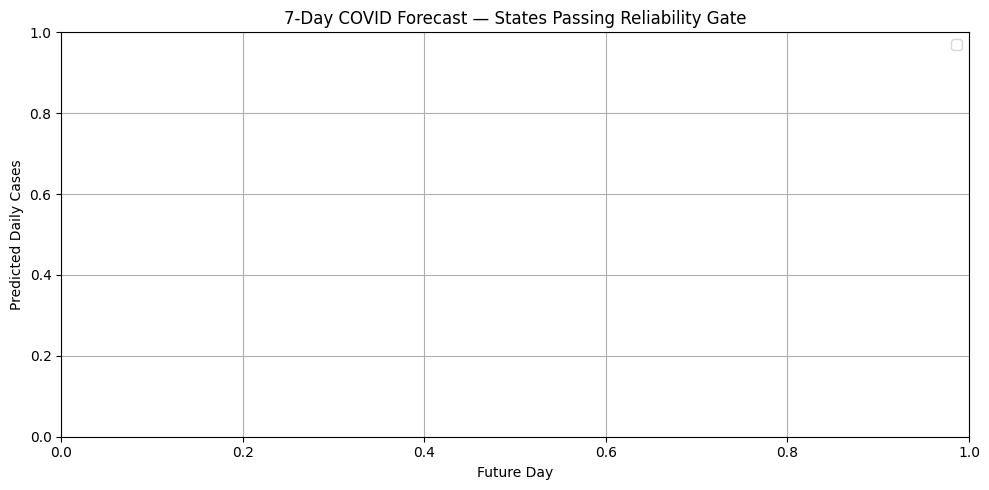

In [62]:
# Show only forecasts that pass BOTH production reliability criteria:
# 1) broader held-out test beats persistence
# 2) rolling 7-day validation passes (>= 3/4 windows)

plt.figure(figsize=(10, 5))

for st, preds in state_forecasts.items():
    test_pass = bool(state_metrics[st]["beats_naive"])
    rolling_pass = bool(
        rolling_summary.loc[st, "rolling_pass"]
        if st in rolling_summary.index
        else False
    )

    if test_pass and rolling_pass:
        plt.plot(
            range(1, FORECAST_DAYS + 1),
            preds,
            marker="o",
            label=st,
        )

plt.title("7-Day COVID Forecast — States Passing Reliability Gate")
plt.xlabel("Future Day")
plt.ylabel("Predicted Daily Cases")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [63]:
day7_stress = []
labels = []

for st, preds in state_forecasts.items():
    test_pass = bool(state_metrics[st]["beats_naive"])
    rolling_pass = bool(
        rolling_summary.loc[st, "rolling_pass"]
        if st in rolling_summary.index
        else False
    )

    if not (test_pass and rolling_pass):
        continue

    p = preds[-1]
    beds = state_beds.get(st)

    if beds is None:
        continue

    stress = (p * 0.05) / beds
    day7_stress.append(stress)
    labels.append(f"{st}\n({stress_level(stress)})")

if day7_stress:
    plt.figure(figsize=(8, 5))
    plt.bar(labels, day7_stress)
    plt.title("Healthcare Stress by State (Day 7, illustrative)")
    plt.xlabel("State")
    plt.ylabel("Stress Index")
    plt.grid(axis="y")
    plt.tight_layout()
    plt.show()
else:
    print(
        "No state passed BOTH forecast reliability criteria; "
        "stress chart withheld."
    )


No state passed BOTH forecast reliability criteria; stress chart withheld.


In [65]:
print("FINAL state_metrics:")
display(pd.DataFrame(state_metrics).T)

print("\nFINAL backtest_results:")
display(pd.DataFrame(backtest_results).T)

print("\nFINAL rolling_summary:")
display(rolling_summary)

FINAL state_metrics:


,mae,rmse,naive_mae,naive_rmse,target_mean,beats_naive,mae_by_horizon,rmse_by_horizon,naive_mae_by_horizon,naive_rmse_by_horizon,selected_config,validation_results,test_start_index,test_end_index
TN,10497.213733,14881.879416,2265.554887,2865.925463,15207.190977,False,"[10580.616432386361, 10562.10787922269, 10553....","[14990.187486979186, 14952.253397420129, 14925...","[599.6631578947369, 1174.6526315789474, 1739.2...","[816.5814362972399, 1524.5375278044849, 2210.4...","{'n_estimators': 400, 'max_depth': 12, 'min_sa...","[{'config': {'n_estimators': 300, 'max_depth':...",406,501
KA,11284.369522,17323.968742,3088.473684,4593.877783,15763.633083,False,"[10811.24257833677, 10944.941638475604, 11142....","[17111.920296383967, 17203.251838284286, 17378...","[2013.4842105263158, 2233.821052631579, 2556.0...","[3262.1069636210987, 3385.0115804824068, 3971....","{'n_estimators': 300, 'max_depth': 8, 'min_sam...","[{'config': {'n_estimators': 300, 'max_depth':...",406,501
MH,6741.32772,11350.76465,3508.27218,5470.193411,19889.882707,False,"[4621.905930275354, 5245.1707442619545, 5884.6...","[7876.415111571034, 9069.481579098485, 10184.6...","[2374.8526315789472, 3104.1473684210528, 3173....","[3927.5963172885968, 4838.44614030492, 5183.57...","{'n_estimators': 400, 'max_depth': 12, 'min_sa...","[{'config': {'n_estimators': 300, 'max_depth':...",406,501
DL,2494.220057,5088.115076,1207.251128,2395.395991,3807.162406,False,"[1840.8806332829743, 1939.546299483731, 2231.9...","[3665.1926588409615, 3836.739312744251, 4391.0...","[554.0842105263158, 789.5368421052632, 977.957...","[1148.433945125182, 1746.7923866634133, 2065.8...","{'n_estimators': 500, 'max_depth': None, 'min_...","[{'config': {'n_estimators': 300, 'max_depth':...",406,501
KL,12471.66734,15953.153701,3986.206015,5334.718739,20229.133835,False,"[12839.333120437454, 12979.51925304834, 13386....","[16447.362530962564, 16602.3200176297, 16773.0...","[3314.4736842105262, 4131.284210526316, 4234.0...","[4442.762799738114, 5626.45589112159, 5623.099...","{'n_estimators': 400, 'max_depth': 12, 'min_sa...","[{'config': {'n_estimators': 300, 'max_depth':...",406,501



FINAL backtest_results:


,backtest_mae,naive_mae,beats_naive,mae_by_horizon,naive_mae_by_horizon
TN,302.45975,150.857143,False,"[74.25375324675406, 203.00914078282858, 314.50...","[11.0, 92.0, 180.0, 219.0, 223.0, 190.0, 141.0]"
KA,244.925438,317.0,True,"[81.52892991054591, 376.6446431375359, 223.670...","[30.0, 551.0, 389.0, 486.0, 374.0, 216.0, 173.0]"
MH,477.349652,641.285714,True,"[271.9009661796481, 743.8928643578702, 162.242...","[599.0, 984.0, 342.0, 701.0, 221.0, 1389.0, 25..."
DL,12.757328,18.571429,True,"[11.93327388167387, 18.31750988455984, 0.72047...","[10.0, 26.0, 14.0, 19.0, 8.0, 26.0, 27.0]"
KL,2039.922151,2013.285714,False,"[1946.2345218253868, 1759.8912081807139, 754.1...","[73.0, 65.0, 1357.0, 1505.0, 1401.0, 8145.0, 1..."



FINAL rolling_summary:


,windows_tested,windows_won,win_rate,rolling_pass
state,,,,
TN,4,1,0.25,False
KA,4,4,1.00,True
MH,4,3,0.75,True
DL,4,1,0.25,False
KL,4,1,0.25,False


## 10. Save Artifacts

The saved state models are **production direct 7-day models** retrained on all
available historical data.

Evaluation metrics and the forecast-gate decision are stored in metadata so
the Streamlit app does not need hardcoded results.


In [64]:
ARTIFACT_DIR = Path("artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)

# Save the production models using the filenames expected by the Streamlit app.
for st, m in state_models.items():
    joblib.dump(m, ARTIFACT_DIR / f"state_model_{st}.pkl")

joblib.dump(national_model, ARTIFACT_DIR / "national_model.pkl")

state_metrics_serializable = {
    st: {
        k: (
            float(v)
            if isinstance(v, (np.floating, float))
            else v
        )
        for k, v in row.items()
    }
    for st, row in state_metrics.items()
}

backtest_serializable = {
    st: {
        k: (
            float(v)
            if isinstance(v, (np.floating, float))
            else v
        )
        for k, v in row.items()
    }
    for st, row in backtest_results.items()
}

rolling_serializable = {
    st: [
        {
            "window": int(r["window"]),
            "model_mae": float(r["model_mae"]),
            "naive_mae": float(r["naive_mae"]),
            "beats_naive": bool(r["beats_naive"]),
        }
        for r in rows
    ]
    for st, rows in rolling_results.items()
}

rolling_summary_serializable = {
    st: {
        "windows_tested": int(row["windows_tested"]),
        "windows_won": int(row["windows_won"]),
        "win_rate": float(row["win_rate"]),
        "rolling_pass": bool(row["rolling_pass"]),
    }
    for st, row in rolling_summary.iterrows()
}

metadata = {
    "features": FEATURES,
    "forecast_type": "direct_multi_output_7_day",
    "forecast_days": FORECAST_DAYS,

    "feature_target_design": {
        "features": "training-derived capped case-count history",
        "targets": "original uncapped future case counts",
        "evaluation": "original uncapped observed case counts",
    },

    "growth_clip": GROWTH_CLIP,
    "outlier_quantile": OUTLIER_QUANTILE,
    "sanity_bound_pct": SANITY_BOUND_PCT,

    "states_modeled": list(state_models.keys()),
    "state_outlier_caps": {
        st: float(cap)
        for st, cap in state_caps.items()
    },

    "state_test_metrics": state_metrics_serializable,
    "state_backtest_metrics": backtest_serializable,

    "rolling_7day_validation": rolling_serializable,
    "rolling_7day_summary": rolling_summary_serializable,

    "forecast_gate": {
        "enabled": True,
        "criteria": [
            "broader held-out state test-set MAE must beat persistence",
            "at least 3 of 4 rolling 7-day validation windows must beat persistence",
        ],
        "min_rolling_wins": MIN_ROLLING_WINS,
        "rolling_windows": ROLLING_WINDOWS,
        "failed_forecast_behavior": "withhold forecast number",
        "source_of_truth": "combined state_test_metrics and rolling_7day_summary",
    },
}

with open(ARTIFACT_DIR / "model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

df_state.to_csv(
    ARTIFACT_DIR / "state_data.csv",
    index=False,
)

print("Artifacts saved to:", ARTIFACT_DIR.resolve())
print("State models:", list(state_models.keys()))
print("Rolling validation metadata saved.")


Artifacts saved to: F:\HealthCast-main\notebooks\artifacts
State models: ['TN', 'KA', 'MH', 'DL', 'KL']
Rolling validation metadata saved.


## 11. Limitations

- This project forecasts historical COVID-19 case counts; pandemic dynamics
  from 2020-2022 may not resemble a future outbreak.
- The model uses only historical case counts. It does not include vaccination,
  testing volume, mobility, policy, variant, hospitalization, or weather data.
- Direct 7-day forecasting avoids recursive error propagation, but forecast
  uncertainty can still be substantial.
- A persistence baseline is intentionally strong for short-horizon time-series
  forecasting. The Random Forest must beat it before the app displays a
  state forecast.
- The reliability gate is based on the average MAE across the untouched
  chronological test period. Passing the gate does not guarantee every future
  prediction will be accurate.
- The final 7-day backtest is a separate diagnostic and should not override the
  broader test-set gate.
- Bed-capacity values are illustrative, undated placeholders and must not be
  treated as real healthcare capacity planning.
- Outlier caps are learned from historical training data and are applied only
  to model features. Evaluation targets remain original/uncapped observations.
- The operational sanity bound is a display/business rule, not a learned model
  behavior and is never used to improve evaluation metrics.
- API sources can change or become unavailable; cached CSVs are used as fallback.
